In [45]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt



In [46]:
#Fetch the dataset
df = yf.download("AAPL TSLA", period="1y", interval="1d")

/tmp/ipykernel_512/3290412111.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL TSLA", period="1y", interval="1d")
[*********************100%***********************]  2 of 2 completed


Checking the Data

In [47]:
df.head(10)

Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2025-04-28  209.228104  285.880005  210.582203  294.859985  206.559741   
2025-04-29  210.293442  292.029999  211.318971  293.320007  207.465755   
2025-04-30  211.577850  282.160004  212.653165  284.450012  205.773148   
2025-05-01  212.394302  280.519989  213.628912  290.869995  207.993470   
2025-05-02  204.458893  287.209991  206.091775  294.779999  201.282733   
2025-05-05  198.026917  280.260010  203.214314  284.850006  197.349875   
2025-05-06  197.648560  275.350006  199.779272  277.730011  196.165035   
2025-05-07  195.398376  276.220001  198.574536  277.920013  192.411395   
2025-05-08  196.632996  284.820007  199.181884  289.799988  193.835177   
2025-05-09  197.668472  298.260010  199.669744  307.040009  196.682763   

Price                         Open                 Volume             
Ticker            TSLA        AAPL        TSLA       AAPL       TSLA  
Date                                                                  
2025-04-28  272.420013  209.088712  288.980011   38743100  151731800  
2025-04-29  279.470001  207.784373  285.500000   36827600  108906600  
2025-04-30  270.779999  208.391740  279.899994   52286500  128961100  
2025-05-01  279.809998  208.172696  280.010010   57365700   99659000  
2025-05-02  279.809998  205.195672  284.899994  101010600  114454700  
2025-05-05  274.399994  202.218654  284.570007   69018500   94618900  
2025-05-06  271.350006  197.349874  273.109985   51216500   76715800  
2025-05-07  271.000000  198.305703  276.880005   68536700   71592600  
2025-05-08  279.410004  196.861993  279.630005   50478900   97539400  
2025-05-09  290.000000  198.136434  290.209991   36453900  132387800

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-04-28 to 2026-04-27
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (Close, TSLA)   251 non-null    float64
 2   (High, AAPL)    251 non-null    float64
 3   (High, TSLA)    251 non-null    float64
 4   (Low, AAPL)     251 non-null    float64
 5   (Low, TSLA)     251 non-null    float64
 6   (Open, AAPL)    251 non-null    float64
 7   (Open, TSLA)    251 non-null    float64
 8   (Volume, AAPL)  251 non-null    int64  
 9   (Volume, TSLA)  251 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 21.6 KB


In [49]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
        TSLA      0
High    AAPL      0
        TSLA      0
Low     AAPL      0
        TSLA      0
Open    AAPL      0
        TSLA      0
Volume  AAPL      0
        TSLA      0
dtype: int64

In [50]:
df.shape

(251, 10)

In [51]:
df.describe()

Price        Close                    High                     Low  \
Ticker        AAPL        TSLA        AAPL        TSLA        AAPL   
count   251.000000  251.000000  251.000000  251.000000  251.000000   
mean    243.417760  384.441195  245.779855  391.599203  241.007338   
std      27.271447   55.085720   27.455058   55.767664   27.025224   
min     194.677597  275.350006  196.970599  277.730011  192.411395   
25%     212.498672  334.354996  214.248036  341.774994  210.584179   
50%     253.789993  395.010010  256.130005  402.100006  250.649994   
75%     267.100082  432.209991  270.285936  440.490005  265.070998   
max     285.922455  489.880005  288.350192  498.829987  283.035157   

Price                     Open                    Volume                
Ticker        TSLA        AAPL        TSLA          AAPL          TSLA  
count   251.000000  251.000000  251.000000  2.510000e+02  2.510000e+02  
mean    377.269881  243.365330  384.589243  4.991250e+07  8.374154e+07  
std      54.524855   27.227447   55.463315  1.895865e+07  2.981094e+07  
min     270.779999  193.082445  273.109985  8.143515e+06  1.147651e+07  
25%     328.590012  211.910128  335.480011  3.939560e+07  6.226340e+07  
50%     387.529999  254.075726  395.690002  4.607630e+07  7.769760e+07  
75%     425.260010  266.879990  434.815002  5.460840e+07  9.741210e+07  
max     485.329987  285.932471  489.880005  1.637413e+08  2.874998e+08

The dataset contains 251 observations with no missing values across all columns, indicating high data completeness. The data is well-structured with a DateTime index and numerical values for price and volume. Therefore, no significant data cleaning was required before analysis.

In [52]:
#Extract Close Price
close = df['Close']
close.head(10)

Ticker,AAPL,TSLA
Date,,
2025-04-28,209.228104,285.880005
2025-04-29,210.293442,292.029999
2025-04-30,211.577850,282.160004
2025-05-01,212.394302,280.519989
2025-05-02,204.458893,287.209991
2025-05-05,198.026917,280.260010
2025-05-06,197.648560,275.350006
2025-05-07,195.398376,276.220001
2025-05-08,196.632996,284.820007


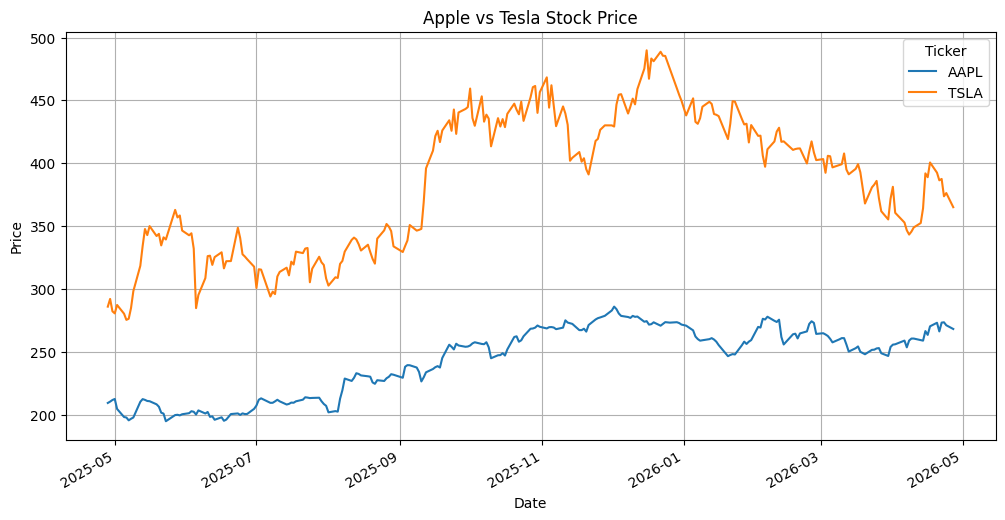

In [53]:
close.plot(figsize=(12,6))
plt.title("Apple vs Tesla Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

Fetch Data with Different Interval & Period

In [54]:
data_1min = yf.download("AAPL", period="5d", interval="1m")
data_1min.head()

/tmp/ipykernel_512/3922611393.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_1min = yf.download("AAPL", period="5d", interval="1m")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-04-21 13:30:00+00:00,272.290009,272.799988,271.232513,271.445007,1740304
2026-04-21 13:31:00+00:00,271.220001,272.589996,271.209991,272.339996,241287
2026-04-21 13:32:00+00:00,270.766815,271.519989,270.649994,271.227997,313960
2026-04-21 13:33:00+00:00,271.054993,271.320007,270.650085,270.774994,149087
2026-04-21 13:34:00+00:00,270.975006,271.269989,270.700012,271.019989,158122


In [55]:
data_weekly = yf.download("AAPL", period="5y", interval="1wk")
data_weekly.head()

/tmp/ipykernel_512/848735980.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_weekly = yf.download("AAPL", period="5y", interval="1wk")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-04-26,128.041443,133.505558,127.661585,131.499115,434716400
2021-05-03,126.823944,130.583567,123.405211,128.606343,453802300
2021-05-10,124.346588,126.385693,119.273211,126.258869,514165600
2021-05-17,122.375763,124.883183,119.868343,123.731916,386352000
2021-05-24,121.575737,125.195405,121.517200,122.941648,357615000


In [56]:
aapl_1min = data_1min.xs('AAPL', axis=1, level=1)

In [57]:
#resample the stock data
data_10min = aapl_1min.resample('10min').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})
data_10min.head()

Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-04-21 13:30:00+00:00,271.445007,272.799988,270.529999,270.899994,3557016
2026-04-21 13:40:00+00:00,270.890015,271.600006,270.651215,271.269989,1091377
2026-04-21 13:50:00+00:00,271.269989,271.880188,271.170013,271.839996,874667
2026-04-21 14:00:00+00:00,271.869995,272.059998,270.769989,270.769989,952298
2026-04-21 14:10:00+00:00,270.774994,270.869995,270.144989,270.144989,978395


Fetch Apple Financial Data

In [58]:
aapl = yf.Ticker("AAPL")

In [59]:
# Apple Revenue
revenue = aapl.financials.loc['Total Revenue']
revenue.head()

,Total Revenue
2025-09-30,4.161610e+11
2024-09-30,3.910350e+11
2023-09-30,3.832850e+11
2022-09-30,3.943280e+11
2021-09-30,NaN


In [60]:
revenue = revenue.dropna()

In [61]:
revenue = revenue.sort_index()
revenue.head()

,Total Revenue
2022-09-30,3.943280e+11
2023-09-30,3.832850e+11
2024-09-30,3.910350e+11
2025-09-30,4.161610e+11


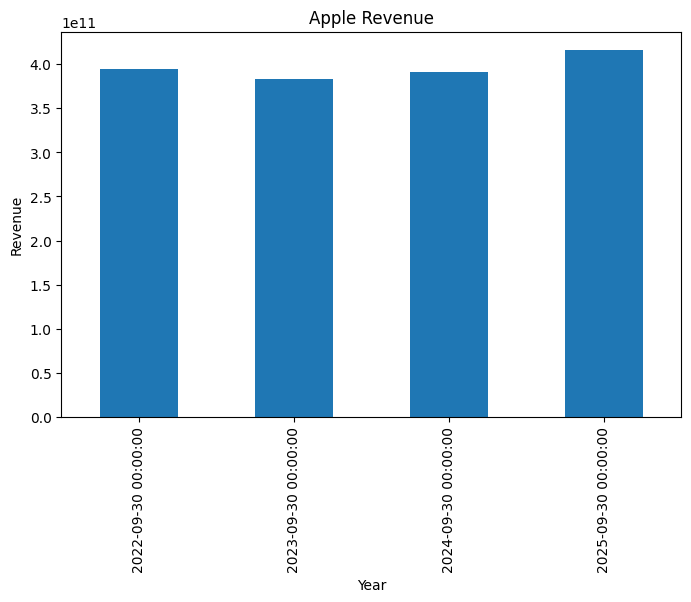

In [62]:
revenue.plot(kind='bar', figsize=(8,5))
plt.title("Apple Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

In [63]:
#Earnings Before Interest and Taxes
ebit = aapl.financials.loc['EBIT']
ebit.head()

,EBIT
2025-09-30,1.330500e+11
2024-09-30,1.232160e+11
2023-09-30,1.143010e+11
2022-09-30,1.194370e+11
2021-09-30,NaN


In [64]:
ebit = ebit.dropna()
ebit.head()

,EBIT
2025-09-30,1.330500e+11
2024-09-30,1.232160e+11
2023-09-30,1.143010e+11
2022-09-30,1.194370e+11


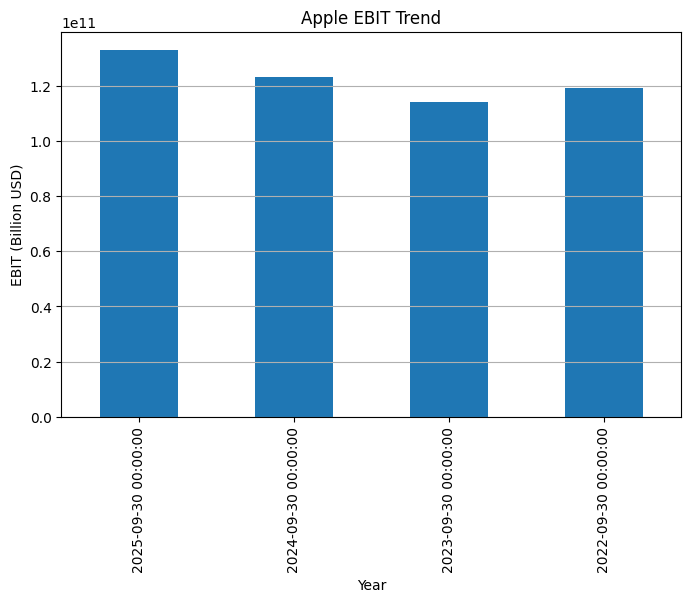

In [65]:
ebit.plot(kind='bar', figsize=(8,5))

plt.title("Apple EBIT Trend")
plt.xlabel("Year")
plt.ylabel("EBIT (Billion USD)")
plt.grid(axis='y')

plt.show()

In [69]:
net_income = aapl.financials.loc['Net Income']
net_income

,Net Income
2025-09-30,1.120100e+11
2024-09-30,9.373600e+10
2023-09-30,9.699500e+10
2022-09-30,9.980300e+10
2021-09-30,NaN


In [70]:
net_income = net_income.dropna()
net_income.head()

,Net Income
2025-09-30,1.120100e+11
2024-09-30,9.373600e+10
2023-09-30,9.699500e+10
2022-09-30,9.980300e+10


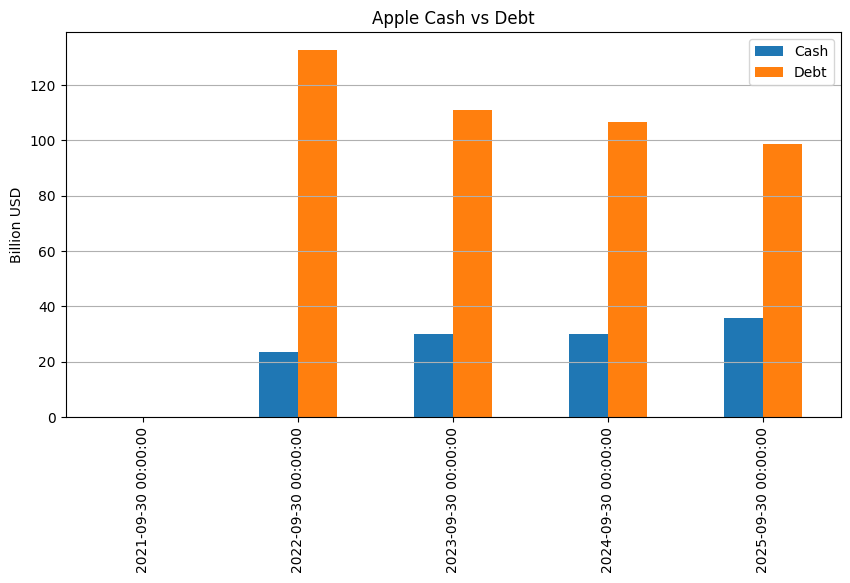

In [79]:
cash = aapl.balance_sheet.loc['Cash And Cash Equivalents']
debt = aapl.balance_sheet.loc['Total Debt']

df = pd.DataFrame({
    "Cash": cash,
    "Debt": debt
})

df = df.sort_index() / 1e9

df.plot(kind='bar', figsize=(10,5))

plt.title("Apple Cash vs Debt")
plt.ylabel("Billion USD")
plt.grid(axis='y')
plt.show()

In [44]:
aapl.cashflow

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Free Cash Flow,9.876700e+10,1.088070e+11,9.958400e+10,1.114430e+11,NaN
Repurchase Of Capital Stock,-9.071100e+10,-9.494900e+10,-7.755000e+10,-8.940200e+10,NaN
Repayment Of Debt,-1.093200e+10,-9.958000e+09,-1.115100e+10,-9.543000e+09,NaN
Issuance Of Debt,4.481000e+09,0.000000e+00,5.228000e+09,5.465000e+09,NaN
Issuance Of Capital Stock,NaN,NaN,NaN,NaN,1.105000e+09
Capital Expenditure,-1.271500e+10,-9.447000e+09,-1.095900e+10,-1.070800e+10,NaN
Interest Paid Supplemental Data,NaN,NaN,3.803000e+09,2.865000e+09,2.687000e+09
Income Tax Paid Supplemental Data,4.336900e+10,2.610200e+10,1.867900e+10,1.957300e+10,NaN
End Cash Position,3.593400e+10,2.994300e+10,3.073700e+10,2.497700e+10,NaN
Beginning Cash Position,2.994300e+10,3.073700e+10,2.497700e+10,3.592900e+10,NaN
